<a href="https://colab.research.google.com/github/RidhiSood22/AI-Based-Portable-Autorefractor-for-Eye-Screening-/blob/main/Capstone_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("kellysanderson/myopia-image-dataset")
print(path)

100%|██████████| 5.61G/5.61G [04:42<00:00, 21.3MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/kellysanderson/myopia-image-dataset/versions/1


In [ ]:
import os
print(os.listdir(path + "/IMAGES"))

['Normal_images', 'Myopia_images']


In [ ]:
import os
import pandas as pd

BASE_DIR = path + "/IMAGES"

image_paths = []
labels = []

for label in ["Myopia_images", "Normal_images"]:   # ← USE EXACT NAMES FROM STEP 1
    class_dir = os.path.join(BASE_DIR, label)

    for file in os.listdir(class_dir):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(class_dir, file))
            labels.append(label)

df = pd.DataFrame({
    'image': image_paths,
    'label': labels
})

print(df.head())
print("Total images:", len(df))

                                               image          label
0  /root/.cache/kagglehub/datasets/kellysanderson...  Myopia_images
1  /root/.cache/kagglehub/datasets/kellysanderson...  Myopia_images
2  /root/.cache/kagglehub/datasets/kellysanderson...  Myopia_images
3  /root/.cache/kagglehub/datasets/kellysanderson...  Myopia_images
4  /root/.cache/kagglehub/datasets/kellysanderson...  Myopia_images
Total images: 124794


In [ ]:
from sklearn.model_selection import train_test_split

# Convert labels
df['label'] = df['label'].map({
    'Myopia_images': 1,
    'Normal_images': 0
})

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

Train size: 99835
Validation size: 24959


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_dataframe(
    train_df,
    x_col='image',
    y_col='label',
    target_size=(128,128),
    batch_size=32,
    class_mode='raw'
)

val_data = datagen.flow_from_dataframe(
    val_df,
    x_col='image',
    y_col='label',
    target_size=(128,128),
    batch_size=32,
    class_mode='raw'
)

Found 99835 validated image filenames.
Found 24959 validated image filenames.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
logger = CSVLogger("training_log.csv")

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[checkpoint, logger]
)

Epoch 1/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9647 - loss: 0.0920

3120/3120 ━━━━━━━━━━━━━━━━━━━━ 405s 128ms/step - accuracy: 0.9767 - loss: 0.0595 - val_accuracy: 0.9844 - val_loss: 0.0381
Epoch 2/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9865 - loss: 0.0346

3120/3120 ━━━━━━━━━━━━━━━━━━━━ 358s 115ms/step - accuracy: 0.9872 - loss: 0.0327 - val_accuracy: 0.9917 - val_loss: 0.0236
Epoch 3/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 331s 106ms/step - accuracy: 0.9909 - loss: 0.0244 - val_accuracy: 0.9910 - val_loss: 0.0294
Epoch 4/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9934 - loss: 0.0182

3120/3120 ━━━━━━━━━━━━━━━━━━━━ 347s 111ms/step - accuracy: 0.9933 - loss: 0.0188 - val_accuracy: 0.9936 - val_loss: 0.0190
Epoch 5/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9946 - loss: 0.0153

3120/3120 ━━━━━━━━━━━━━━━━━━━━ 322s 103ms/step - accuracy: 0.9946 - loss: 0.0149 - val_accuracy: 0.9952 - val_loss: 0.0145
Epoch 6/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9951 - loss: 0.0134

3120/3120 ━━━━━━━━━━━━━━━━━━━━ 307s 98ms/step - accuracy: 0.9951 - loss: 0.0137 - val_accuracy: 0.9961 - val_loss: 0.0122
Epoch 7/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 294s 94ms/step - accuracy: 0.9962 - loss: 0.0117 - val_accuracy: 0.9939 - val_loss: 0.0187
Epoch 8/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 298s 96ms/step - accuracy: 0.9969 - loss: 0.0096 - val_accuracy: 0.9947 - val_loss: 0.0169
Epoch 9/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 301s 97ms/step - accuracy: 0.9968 - loss: 0.0092 - val_accuracy: 0.9961 - val_loss: 0.0145
Epoch 10/10
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 323s 97ms/step - accuracy: 0.9974 - loss: 0.0081 - val_accuracy: 0.9830 - val_loss: 0.0584


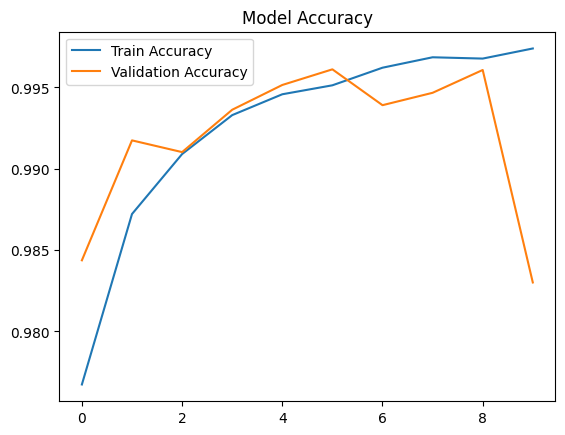

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = df['image'].iloc[0]

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)

if pred[0][0] > 0.5:
    print("Myopia Detected")
else:
    print("Normal Eye")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Myopia Detected
